# 🏦 EBITDA Estimation for Dutch Companies

**Objective:** Train ML models on UK company financials (where EBITDA is known) and apply them to estimate EBITDA for Dutch companies.

**Strategy:**
- UK dataset → Training & testing (EBITDA always present)
- NL dataset with known EBITDA → Out-of-sample validation
- NL dataset with missing EBITDA → Final predictions

**Models compared:** Linear Regression (baseline), Random Forest, XGBoost, Neural Network

**Pipeline:**
1. Install & import libraries
2. Upload data files
3. Data cleaning & preprocessing
4. Feature engineering
5. Train/test split
6. Train models & hyperparameter tuning
7. Compare model performance with visualisations
8. Best model → predict NL EBITDA
9. Export predictions

## Step 1: Install & Load Libraries

In [1]:
# Install required packages (run once)
!pip install pyxlsb xgboost shap --quiet

%env OMP_NUM_THREADS=4
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import xgboost as xgb
import shap

# Plotting style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
PALETTE = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
print('✅ Libraries loaded successfully')

env: OMP_NUM_THREADS=4
✅ Libraries loaded successfully


## Step 2: Upload Data Files

In [7]:
from google.colab import files

print('📁 Please upload the following files:')
print('   1. 20230112_Consolidated_Orbis_extract_UK_companies_v1.xlsb')
print('   2. 20230112_Consolidated_Orbis_extract_Dutch_companies_v1.xlsb')
print()

uploaded = files.upload()
print(f'\n✅ Uploaded: {list(uploaded.keys())}')

📁 Please upload the following files:
   1. 20230112_Consolidated_Orbis_extract_UK_companies_v1.xlsb
   2. 20230112_Consolidated_Orbis_extract_Dutch_companies_v1.xlsb



Saving 20230112 Consolidated Orbis extract UK companies v1.xlsb to 20230112 Consolidated Orbis extract UK companies v1 (2).xlsb
Saving 20230112 Consolidated Orbis extract Dutch companies v1.xlsb to 20230112 Consolidated Orbis extract Dutch companies v1 (1).xlsb

✅ Uploaded: ['20230112 Consolidated Orbis extract UK companies v1 (2).xlsb', '20230112 Consolidated Orbis extract Dutch companies v1 (1).xlsb']


In [18]:
# ─── Load datasets ───────────────────────────────────────────────────────────
print('Loading UK dataset...')
df_uk = pd.read_excel(
    '20230112 Consolidated Orbis extract UK companies v1 (1).xlsb',
    engine='pyxlsb'
)
print(f'  UK: {df_uk.shape[0]:,} rows × {df_uk.shape[1]} columns')

print('Loading Dutch dataset...')
df_nl = pd.read_excel(
    '20230112 Consolidated Orbis extract Dutch companies v1.xlsb',
    engine='pyxlsb'
)
print(f'  NL: {df_nl.shape[0]:,} rows × {df_nl.shape[1]} columns')

# Normalise column names (minor case/spacing differences between files)
def normalise_cols(df):
    df.columns = (
        df.columns.str.replace('\n', ' ', regex=False)
                  .str.strip()
                  .str.lower()
                  .str.replace(r'\s+', '_', regex=True)
                  .str.replace(r'[^a-z0-9_]', '', regex=True)
    )
    return df

df_uk = normalise_cols(df_uk)
df_nl = normalise_cols(df_nl)

print('\nNormalised columns (UK):')
print(df_uk.columns.tolist())

df_uk.head(3)

Loading UK dataset...
  UK: 94,850 rows × 33 columns
Loading Dutch dataset...
  NL: 114,569 rows × 33 columns

Normalised columns (UK):
['company_name_latin_alphabet', 'nace_rev_2_core_code_4_digits', 'nace_rev_2_core_code__description', 'website_address', 'no_of_companies_in_corporate_group', 'bvd_id_number', 'orbis_id_number', 'region_in_country', 'number_of_employees_last_avail_yr', 'number_of_employees_year__1', 'number_of_employees_year__2', 'number_of_employees_year__3', 'number_of_current_directors__managers', 'operating_revenue_turnover_m_eur_last_avail_yr', 'operating_revenue_turnover_m_eur_year__1', 'operating_revenue_turnover_m_eur_year__2', 'operating_revenue_turnover_m_eur_year__3', 'pl_for_period_net_income_m_eur_last_avail_yr', 'pl_for_period_net_income_m_eur_year__1', 'pl_for_period_net_income_m_eur_year__2', 'pl_for_period_net_income_m_eur_year__3', 'other_shareholders_funds_m_eur_last_avail_yr', 'other_shareholders_funds_m_eur_year__1', 'other_shareholders_funds_m_eur

,company_name_latin_alphabet,nace_rev_2_core_code_4_digits,nace_rev_2_core_code__description,website_address,no_of_companies_in_corporate_group,bvd_id_number,orbis_id_number,region_in_country,number_of_employees_last_avail_yr,number_of_employees_year__1,...,other_shareholders_funds_m_eur_year__2,other_shareholders_funds_m_eur_year__3,total_assets_m_eur_last_avail_yr,total_assets_m_eur_year__1,total_assets_m_eur_year__2,total_assets_m_eur_year__3,ebitda_m_eur_last_avail_yr,ebitda_m_eur_year__1,ebitda_m_eur_year__2,ebitda_m_eur_year__3
0,S.D. TAYLOR LIMITED,6492.0,Other credit granting,www.loansathome.co.uk,12.0,GB00550055,3942779,England,305,313,...,19.300469,25.861478,41.207138,60.41801,58.364875,71.367766,0.033903,13.517459,8.76155,4.871489
1,INVESTIS DIGITAL TOPCO LIMITED,6209.0,Other information technology and computer serv...,www.investis.com,16.0,GB08185143,137709088,England,512,494,...,-51.380693,-44.128436,66.435149,71.23735,62.022728,67.132815,8.281017,7.393547,9.528823,-2.673461
2,S&I HOLDINGS LIMITED,6420.0,Activities of holding companies,sigroundworks.co.uk,3.0,GB09362291,197261601,England,21,13,...,1.353548,0.916094,14.018399,6.357188,5.886601,6.160177,2.513321,1.745867,1.366382,0.937883


## Step 3: Data Cleaning & Preprocessing

In [9]:
# ─── Identify column groups ───────────────────────────────────────────────────
# After normalisation, columns follow predictable patterns
# We'll identify them programmatically to be robust to minor name changes

def get_col(df, keyword):
    """Return first column name containing all keywords."""
    for col in df.columns:
        if all(k in col for k in keyword):
            return col
    return None

def get_cols(df, keyword):
    """Return all columns containing all keywords."""
    return [c for c in df.columns if all(k in c for k in keyword)]

# Map logical names → actual column names
COL_MAP = {
    'company_name': 'company_name_latin_alphabet',
    'nace_code': 'nace_rev_2_core_code_4_digits',
    'nace_desc': 'nace_rev_2_core_code__description',
    'region': 'region_in_country',
    'corp_group_size': 'no_of_companies_in_corporate_group',
    'n_directors': 'number_of_current_directors__managers',
}

# Numeric time-series columns (last yr + 3 historical)
TS_MAP = {
    'employees': 'number_of_employees',
    'revenue': 'operating_revenue_turnover',
    'net_income': 'pl_for_period_net_income',
    'shareholders_funds': 'other_shareholders_funds',
    'total_assets': 'total_assets',
    'ebitda': 'ebitda',
}

def resolve_ts_cols(df, base_keyword):
    """Get [last_yr, yr-1, yr-2, yr-3] columns for a metric."""
    candidates = [c for c in df.columns if base_keyword in c]
    order = ['last', 'year__1', 'year__2', 'year__3']
    result = []
    for tag in order:
        match = [c for c in candidates if tag in c]
        result.append(match[0] if match else None)
    return result  # [last_yr, yr-1, yr-2, yr-3]

# ─── Convert numeric columns ──────────────────────────────────────────────────
def to_numeric_df(df, base_keywords):
    """Convert all time-series columns to numeric, replacing 'n.a.' etc."""
    for metric, keyword in base_keywords.items():
        cols = [c for c in df.columns if keyword in c]
        for col in cols:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

df_uk = to_numeric_df(df_uk, TS_MAP)
df_nl = to_numeric_df(df_nl, TS_MAP)

# ─── EBITDA target column detection ──────────────────────────────────────────
ebitda_cols_uk = resolve_ts_cols(df_uk, 'ebitda')
ebitda_cols_nl = resolve_ts_cols(df_nl, 'ebitda')
TARGET_UK = ebitda_cols_uk[0]   # last available year
TARGET_NL = ebitda_cols_nl[0]
print(f'Target column (UK): {TARGET_UK}')
print(f'Target column (NL): {TARGET_NL}')

# ─── Missingness overview ─────────────────────────────────────────────────────
print(f'\nUK EBITDA missing: {df_uk[TARGET_UK].isna().sum():,} / {len(df_uk):,} '
      f'({100*df_uk[TARGET_UK].isna().mean():.1f}%)')
print(f'NL EBITDA missing: {df_nl[TARGET_NL].isna().sum():,} / {len(df_nl):,} '
      f'({100*df_nl[TARGET_NL].isna().mean():.1f}%)')

Target column (UK): ebitda_m_eur_last_avail_yr
Target column (NL): ebitda_m_eur_last_avail_yr

UK EBITDA missing: 21,518 / 94,850 (22.7%)
NL EBITDA missing: 109,028 / 114,569 (95.2%)


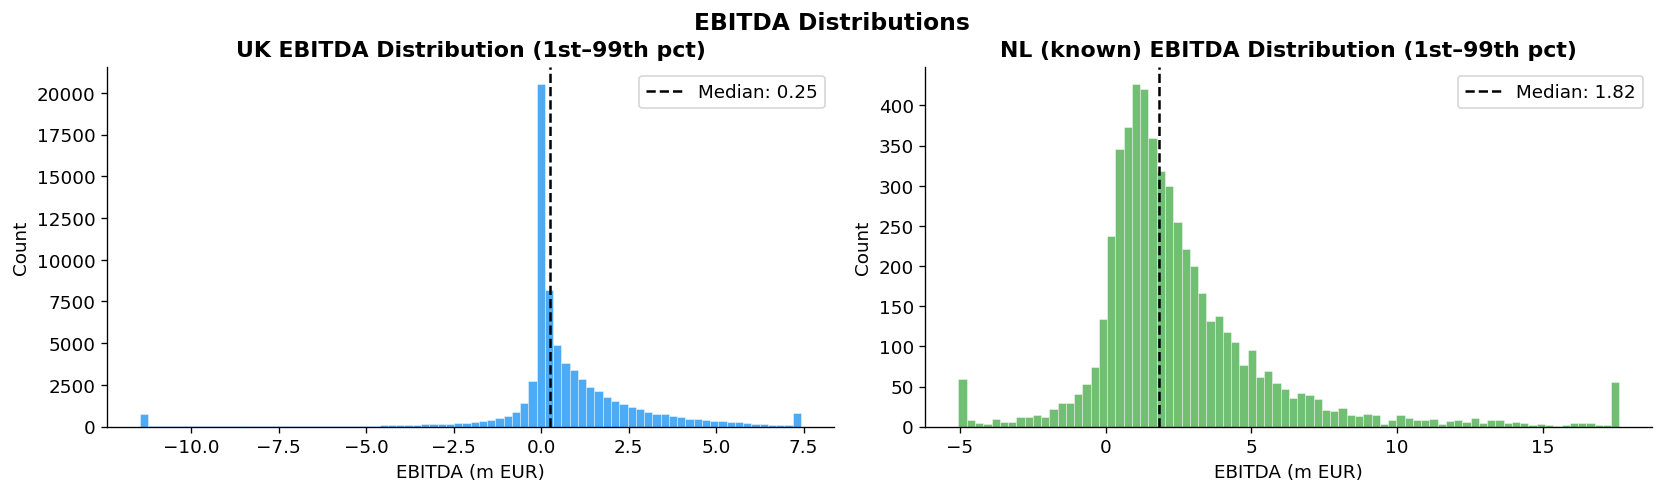

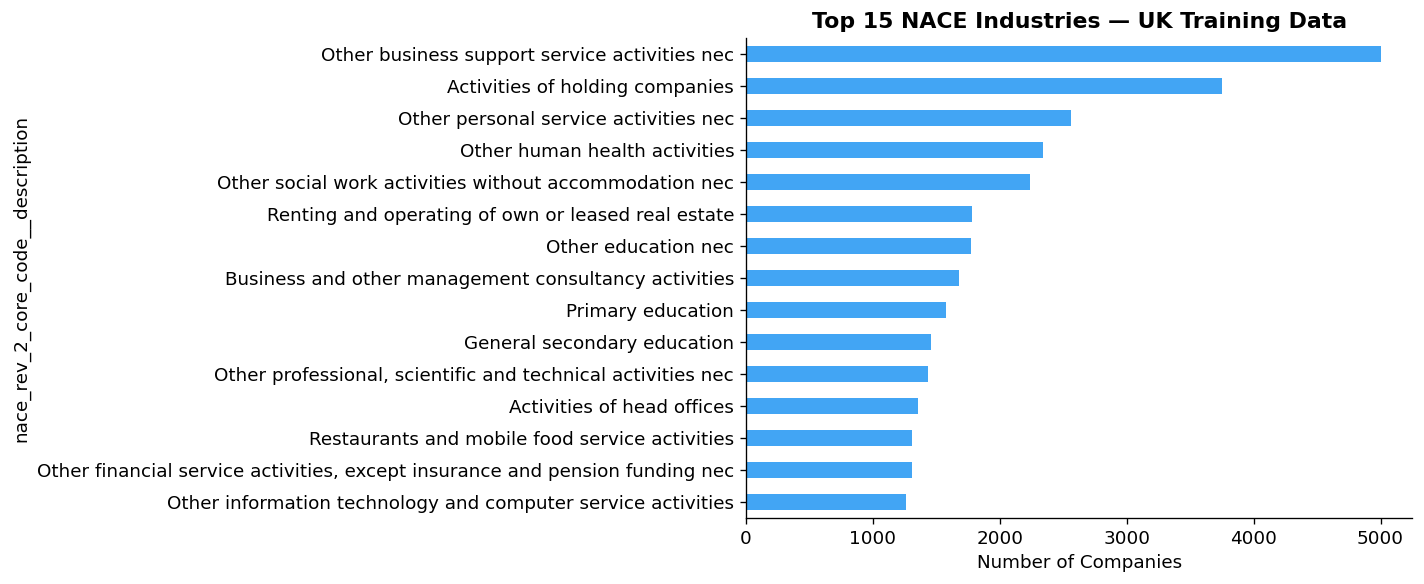

In [10]:
# ─── Exploratory Data Analysis ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, df, label, color in [
    (axes[0], df_uk, 'UK', PALETTE[0]),
    (axes[1], df_nl, 'NL (known)', PALETTE[1])
]:
    target = TARGET_UK if label == 'UK' else TARGET_NL
    vals = df[target].dropna()
    # Clip extreme outliers for visualisation
    p1, p99 = vals.quantile([0.01, 0.99])
    vals_clipped = vals.clip(p1, p99)
    ax.hist(vals_clipped, bins=80, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.set_title(f'{label} EBITDA Distribution (1st–99th pct)', fontweight='bold')
    ax.set_xlabel('EBITDA (m EUR)')
    ax.set_ylabel('Count')
    ax.axvline(vals.median(), color='black', linestyle='--', linewidth=1.5,
               label=f'Median: {vals.median():.2f}')
    ax.legend()

plt.tight_layout()
plt.suptitle('EBITDA Distributions', y=1.02, fontsize=14, fontweight='bold')
plt.show()

# Top NACE industries in UK training data
nace_col = [c for c in df_uk.columns if 'nace' in c and 'description' in c][0]
top_nace = df_uk[nace_col].value_counts().head(15)
fig, ax = plt.subplots(figsize=(12, 5))
top_nace.plot(kind='barh', ax=ax, color=PALETTE[0], alpha=0.85)
ax.set_title('Top 15 NACE Industries — UK Training Data', fontweight='bold')
ax.set_xlabel('Number of Companies')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Step 4: Feature Engineering

In [11]:
# ─── Feature Engineering ─────────────────────────────────────────────────────
#
# For each company we compute:
# (a) Latest-year snapshots of each financial metric
# (b) Year-over-year growth rates (revenue, employees, assets)
# (c) Profitability / efficiency ratios
# (d) NACE sector (numeric + one-hot for top-N sectors)
# (e) Region encoding

def engineer_features(df, target_col, is_training=True):
    """
    Parameters
    ----------
    df          : raw dataframe
    target_col  : name of EBITDA column to use as label (only for training)
    is_training : whether to keep target variable (False for NL prediction set)
    """
    out = pd.DataFrame(index=df.index)

    # ── helper: safely grab column ────────────────────────────────────────────
    def safe(keyword_list):
        """Return series for first matching column, else NaN series."""
        for kw in keyword_list:
            matches = [c for c in df.columns if all(k in c for k in kw.split('|'))]
            if matches:
                return df[matches[0]].apply(pd.to_numeric, errors='coerce')
        return pd.Series(np.nan, index=df.index)

    rev_cols  = resolve_ts_cols(df, 'operating_revenue')
    emp_cols  = resolve_ts_cols(df, 'number_of_employees')
    ni_cols   = resolve_ts_cols(df, 'pl_for_period')
    sf_cols   = resolve_ts_cols(df, 'shareholders_funds')
    ta_cols   = resolve_ts_cols(df, 'total_assets')

    def get(cols, idx):
        c = cols[idx]
        if c: return df[c].apply(pd.to_numeric, errors='coerce')
        return pd.Series(np.nan, index=df.index)

    # ── Level features ────────────────────────────────────────────────────────
    out['rev_last']  = get(rev_cols,  0)
    out['rev_yr1']   = get(rev_cols,  1)
    out['rev_yr2']   = get(rev_cols,  2)
    out['emp_last']  = get(emp_cols,  0)
    out['emp_yr1']   = get(emp_cols,  1)
    out['ni_last']   = get(ni_cols,   0)
    out['ni_yr1']    = get(ni_cols,   1)
    out['sf_last']   = get(sf_cols,   0)
    out['sf_yr1']    = get(sf_cols,   1)
    out['ta_last']   = get(ta_cols,   0)
    out['ta_yr1']    = get(ta_cols,   1)
    out['ta_yr2']    = get(ta_cols,   2)

    # ── YoY growth rates ──────────────────────────────────────────────────────
    def yoy(new_s, old_s):
        denom = old_s.replace(0, np.nan)
        return ((new_s - old_s) / denom.abs()).clip(-5, 5)

    out['rev_growth_1y']  = yoy(out['rev_last'], out['rev_yr1'])
    out['rev_growth_2y']  = yoy(out['rev_yr1'],  out['rev_yr2'])
    out['emp_growth_1y']  = yoy(out['emp_last'], out['emp_yr1'])
    out['ta_growth_1y']   = yoy(out['ta_last'],  out['ta_yr1'])
    out['ta_growth_2y']   = yoy(out['ta_yr1'],   out['ta_yr2'])
    out['ni_growth_1y']   = yoy(out['ni_last'],  out['ni_yr1'])

    # ── Ratio / efficiency features ───────────────────────────────────────────
    out['net_margin']     = (out['ni_last'] / out['rev_last'].replace(0, np.nan)).clip(-5, 5)
    out['asset_turnover'] = (out['rev_last'] / out['ta_last'].replace(0, np.nan)).clip(0, 20)
    out['equity_ratio']   = (out['sf_last'] / out['ta_last'].replace(0, np.nan)).clip(-2, 2)
    out['rev_per_emp']    = (out['rev_last'] / out['emp_last'].replace(0, np.nan)).clip(0, 50)
    out['ni_per_emp']     = (out['ni_last']  / out['emp_last'].replace(0, np.nan)).clip(-5, 5)

    # ── Structural features ───────────────────────────────────────────────────
    corp_col = [c for c in df.columns if 'no_of_companies' in c]
    if corp_col:
        out['corp_group_size'] = df[corp_col[0]].apply(pd.to_numeric, errors='coerce').clip(0, 500)

    dir_col = [c for c in df.columns if 'directors' in c]
    if dir_col:
        out['n_directors'] = df[dir_col[0]].apply(pd.to_numeric, errors='coerce').clip(0, 100)

    # ── NACE sector encoding ──────────────────────────────────────────────────
    nace_num_col = [c for c in df.columns if 'nace' in c and 'description' not in c][0]
    nace_desc_col = [c for c in df.columns if 'nace' in c and 'description' in c][0]

    # Raw 4-digit code as numeric
    out['nace_code_num'] = pd.to_numeric(df[nace_num_col], errors='coerce')
    # Sector letter (first char of description word → broad sector)
    # Extract 2-digit NACE division (first 2 digits)
    out['nace_division'] = out['nace_code_num'].apply(
        lambda x: int(str(int(x))[:2]) if pd.notna(x) and x > 0 else np.nan
    )

    # One-hot top 20 divisions
    top_divs = out['nace_division'].value_counts().head(20).index.tolist()
    for div in top_divs:
        out[f'nace_div_{int(div)}'] = (out['nace_division'] == div).astype(int)

    # ── Region encoding ───────────────────────────────────────────────────────
    reg_col = [c for c in df.columns if 'region' in c][0]
    top_regions = df[reg_col].value_counts().head(20).index.tolist()
    for reg in top_regions:
        safe_name = str(reg).lower().replace(' ', '_').replace('-', '_')[:20]
        out[f'region_{safe_name}'] = (df[reg_col] == reg).astype(int)

    # ── Log-transforms for skewed monetary variables ──────────────────────────
    for col in ['rev_last', 'rev_yr1', 'ta_last', 'ta_yr1', 'emp_last']:
        s = out[col]
        out[f'log_{col}'] = np.log1p(s.clip(lower=0))

    # ── Target ───────────────────────────────────────────────────────────────
    if is_training and target_col:
        out['ebitda_target'] = df[target_col].apply(pd.to_numeric, errors='coerce')

    return out

print('Engineering UK features...')
feat_uk = engineer_features(df_uk, TARGET_UK, is_training=True)
print(f'  UK feature matrix: {feat_uk.shape}')

print('Engineering NL features...')
feat_nl = engineer_features(df_nl, TARGET_NL, is_training=True)  # keep target for validation
print(f'  NL feature matrix: {feat_nl.shape}')

feat_uk.head(3)

Engineering UK features...
  UK feature matrix: (94850, 60)
Engineering NL features...
  NL feature matrix: (114569, 67)


,rev_last,rev_yr1,rev_yr2,emp_last,emp_yr1,ni_last,ni_yr1,sf_last,sf_yr1,ta_last,...,region_northern_ireland,region_jersey_(je),region_guernsey_(gg),region_isle_of_man_(im),log_rev_last,log_rev_yr1,log_ta_last,log_ta_yr1,log_emp_last,ebitda_target
0,47.938472,71.056307,72.264495,305,313.0,-3.847414,3.758678,14.553024,21.263747,41.207138,...,0,0,0,0,3.890564,4.277448,3.742589,4.117703,5.723585,0.033903
1,47.263698,51.045842,38.403575,512,494.0,-11.315859,-11.330932,-72.321102,-65.344705,66.435149,...,0,0,0,0,3.876680,3.952125,4.211166,4.279957,6.240276,8.281017
2,47.442657,27.345823,27.806600,21,13.0,1.837927,1.254993,3.731633,2.196498,14.018399,...,0,0,0,0,3.880381,3.344480,2.709276,1.995678,3.091042,2.513321


## Step 5: Prepare Training, Test & Validation Sets

In [12]:
# ─── Align feature sets (UK & NL may differ in dummies) ──────────────────────
FEATURE_COLS = [c for c in feat_uk.columns if c != 'ebitda_target']

# Keep only common columns between UK and NL (NL may have different region dummies)
common_cols = list(set(FEATURE_COLS) & set([c for c in feat_nl.columns if c != 'ebitda_target']))
common_cols = sorted(common_cols)  # stable ordering

print(f'Total feature columns: {len(FEATURE_COLS)}')
print(f'Common UK/NL feature columns: {len(common_cols)}')

# ─── UK: drop rows with missing target ───────────────────────────────────────
mask_uk_valid = feat_uk['ebitda_target'].notna()
X_uk = feat_uk.loc[mask_uk_valid, common_cols]
y_uk = feat_uk.loc[mask_uk_valid, 'ebitda_target']
print(f'\nUK training-eligible rows: {len(X_uk):,}')

# ─── Remove extreme EBITDA outliers (|z-score| > 5) from training ─────────────
z = (y_uk - y_uk.mean()) / y_uk.std()
mask_no_outlier = z.abs() < 5
X_uk = X_uk[mask_no_outlier]
y_uk = y_uk[mask_no_outlier]
print(f'After outlier removal:     {len(X_uk):,} rows')

# ─── Train / Test split on UK data ───────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_uk, y_uk, test_size=0.2, random_state=42
)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

# ─── NL validation set (NL companies with known EBITDA) ──────────────────────
mask_nl_valid = feat_nl['ebitda_target'].notna()
X_nl_val  = feat_nl.loc[mask_nl_valid, common_cols]
y_nl_val  = feat_nl.loc[mask_nl_valid, 'ebitda_target']

# Remove extreme outliers from NL validation too
z_nl = (y_nl_val - y_nl_val.mean()) / y_nl_val.std()
mask_nl_clean = z_nl.abs() < 5
X_nl_val = X_nl_val[mask_nl_clean]
y_nl_val = y_nl_val[mask_nl_clean]

# ─── NL prediction set (missing EBITDA) ──────────────────────────────────────
X_nl_pred = feat_nl.loc[~mask_nl_valid, common_cols]

print(f'\nNL validation set (known EBITDA): {len(X_nl_val):,}')
print(f'NL prediction set (missing EBITDA): {len(X_nl_pred):,}')

# ─── Impute missing feature values ───────────────────────────────────────────
imputer = SimpleImputer(strategy='median')
X_train_imp  = imputer.fit_transform(X_train)
X_test_imp   = imputer.transform(X_test)
X_nl_val_imp = imputer.transform(X_nl_val)
X_nl_pred_imp= imputer.transform(X_nl_pred)

# ─── Scale (for Ridge + Neural Network) ──────────────────────────────────────
scaler = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train_imp)
X_test_sc   = scaler.transform(X_test_imp)
X_nl_val_sc = scaler.transform(X_nl_val_imp)
X_nl_pred_sc= scaler.transform(X_nl_pred_imp)

print('\n✅ Data preparation complete')

Total feature columns: 59
Common UK/NL feature columns: 43

UK training-eligible rows: 73,332
After outlier removal:     73,235 rows
Train: 58,588 | Test: 14,647

NL validation set (known EBITDA): 5,534
NL prediction set (missing EBITDA): 109,028

✅ Data preparation complete


## Step 6: Train Models

In [13]:
# ─── Model 1: Ridge Regression (Baseline) ────────────────────────────────────
from sklearn.linear_model import RidgeCV

print('Training Ridge Regression (baseline)...')
ridge = RidgeCV(alphas=np.logspace(-3, 4, 20), cv=5)
ridge.fit(X_train_sc, y_train)
y_pred_ridge_test = ridge.predict(X_test_sc)
y_pred_ridge_nl   = ridge.predict(X_nl_val_sc)

print(f'  Best alpha: {ridge.alpha_:.4f}')
print(f'  Test  R²: {r2_score(y_test, y_pred_ridge_test):.4f} | '
      f'MAE: {mean_absolute_error(y_test, y_pred_ridge_test):.4f}')
print(f'  NL-Val R²: {r2_score(y_nl_val, y_pred_ridge_nl):.4f} | '
      f'MAE: {mean_absolute_error(y_nl_val, y_pred_ridge_nl):.4f}')

Training Ridge Regression (baseline)...
  Best alpha: 4281.3324
  Test  R²: 0.4183 | MAE: 0.9205
  NL-Val R²: -1.5932 | MAE: 1.9318


In [14]:
# ─── Model 2: Random Forest ───────────────────────────────────────────────────
print('Training Random Forest...')
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train_imp, y_train)
y_pred_rf_test = rf.predict(X_test_imp)
y_pred_rf_nl   = rf.predict(X_nl_val_imp)

print(f'  Test  R²: {r2_score(y_test, y_pred_rf_test):.4f} | '
      f'MAE: {mean_absolute_error(y_test, y_pred_rf_test):.4f}')
print(f'  NL-Val R²: {r2_score(y_nl_val, y_pred_rf_nl):.4f} | '
      f'MAE: {mean_absolute_error(y_nl_val, y_pred_rf_nl):.4f}')

Training Random Forest...
  Test  R²: 0.6279 | MAE: 0.5668
  NL-Val R²: 0.2399 | MAE: 1.6529


In [15]:
# ─── Model 3: XGBoost ────────────────────────────────────────────────────────
print('Training XGBoost...')

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    tree_method='hist',
    eval_metric='rmse',
    early_stopping_rounds=30,
    random_state=42,
    verbosity=0
)
xgb_model.fit(
    X_train_imp, y_train,
    eval_set=[(X_test_imp, y_test)],
    verbose=100
)
y_pred_xgb_test = xgb_model.predict(X_test_imp)
y_pred_xgb_nl   = xgb_model.predict(X_nl_val_imp)

print(f'\n  Best iteration: {xgb_model.best_iteration}')
print(f'  Test  R²: {r2_score(y_test, y_pred_xgb_test):.4f} | '
      f'MAE: {mean_absolute_error(y_test, y_pred_xgb_test):.4f}')
print(f'  NL-Val R²: {r2_score(y_nl_val, y_pred_xgb_nl):.4f} | '
      f'MAE: {mean_absolute_error(y_nl_val, y_pred_xgb_nl):.4f}')

Training XGBoost...
[0]	validation_0-rmse:2.78695
[100]	validation_0-rmse:1.67625
[200]	validation_0-rmse:1.63205
[300]	validation_0-rmse:1.61750
[363]	validation_0-rmse:1.61668

  Best iteration: 333
  Test  R²: 0.6834 | MAE: 0.5123
  NL-Val R²: 0.3980 | MAE: 1.3598


In [16]:
# ─── Model 4: Neural Network (MLP) ───────────────────────────────────────────
print('Training Neural Network...')
nn = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    learning_rate_init=1e-3,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)
nn.fit(X_train_sc, y_train)
y_pred_nn_test = nn.predict(X_test_sc)
y_pred_nn_nl   = nn.predict(X_nl_val_sc)

print(f'  Iterations ran: {nn.n_iter_}')
print(f'  Test  R²: {r2_score(y_test, y_pred_nn_test):.4f} | '
      f'MAE: {mean_absolute_error(y_test, y_pred_nn_test):.4f}')
print(f'  NL-Val R²: {r2_score(y_nl_val, y_pred_nn_nl):.4f} | '
      f'MAE: {mean_absolute_error(y_nl_val, y_pred_nn_nl):.4f}')

Training Neural Network...
  Iterations ran: 25
  Test  R²: 0.6267 | MAE: 0.6029
  NL-Val R²: -0.0264 | MAE: 1.4837


## Step 7: Model Comparison & Visualisations

In [20]:
# ─── Collect all metrics ─────────────────────────────────────────────────────
def metrics(y_true, y_pred, label, dataset):
    return {
        'Model': label,
        'Dataset': dataset,
        'R²': round(r2_score(y_true, y_pred), 4),
        'MAE': round(mean_absolute_error(y_true, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
    }

results = pd.DataFrame([
    metrics(y_test,   y_pred_ridge_test, 'Ridge',   'UK Test'),
    metrics(y_nl_val, y_pred_ridge_nl,   'Ridge',   'NL Validation'),
    metrics(y_test,   y_pred_rf_test,    'Random Forest', 'UK Test'),
    metrics(y_nl_val, y_pred_rf_nl,      'Random Forest', 'NL Validation'),
    metrics(y_test,   y_pred_xgb_test,   'XGBoost', 'UK Test'),
    metrics(y_nl_val, y_pred_xgb_nl,     'XGBoost', 'NL Validation'),
    metrics(y_test,   y_pred_nn_test,    'Neural Network', 'UK Test'),
    metrics(y_nl_val, y_pred_nn_nl,      'Neural Network', 'NL Validation'),
])

print('\n📊 Model Performance Summary')
print('='*70)
display(results.style
    .background_gradient(subset=['R²'], cmap='Greens')
    .background_gradient(subset=['MAE', 'RMSE'], cmap='Reds_r')
    .format({'R²': '{:.4f}', 'MAE': '{:.4f}', 'RMSE': '{:.4f}'})
)


📊 Model Performance Summary


,Model,Dataset,R²,MAE,RMSE
0,Ridge,UK Test,0.4183,0.9205,2.1897
1,Ridge,NL Validation,-1.5932,1.9318,7.3655
2,Random Forest,UK Test,0.6279,0.5668,1.7515
3,Random Forest,NL Validation,0.2399,1.6529,3.9876
4,XGBoost,UK Test,0.6834,0.5123,1.6154
5,XGBoost,NL Validation,0.3980,1.3598,3.5489
6,Neural Network,UK Test,0.6267,0.6029,1.7542
7,Neural Network,NL Validation,-0.0264,1.4837,4.6339


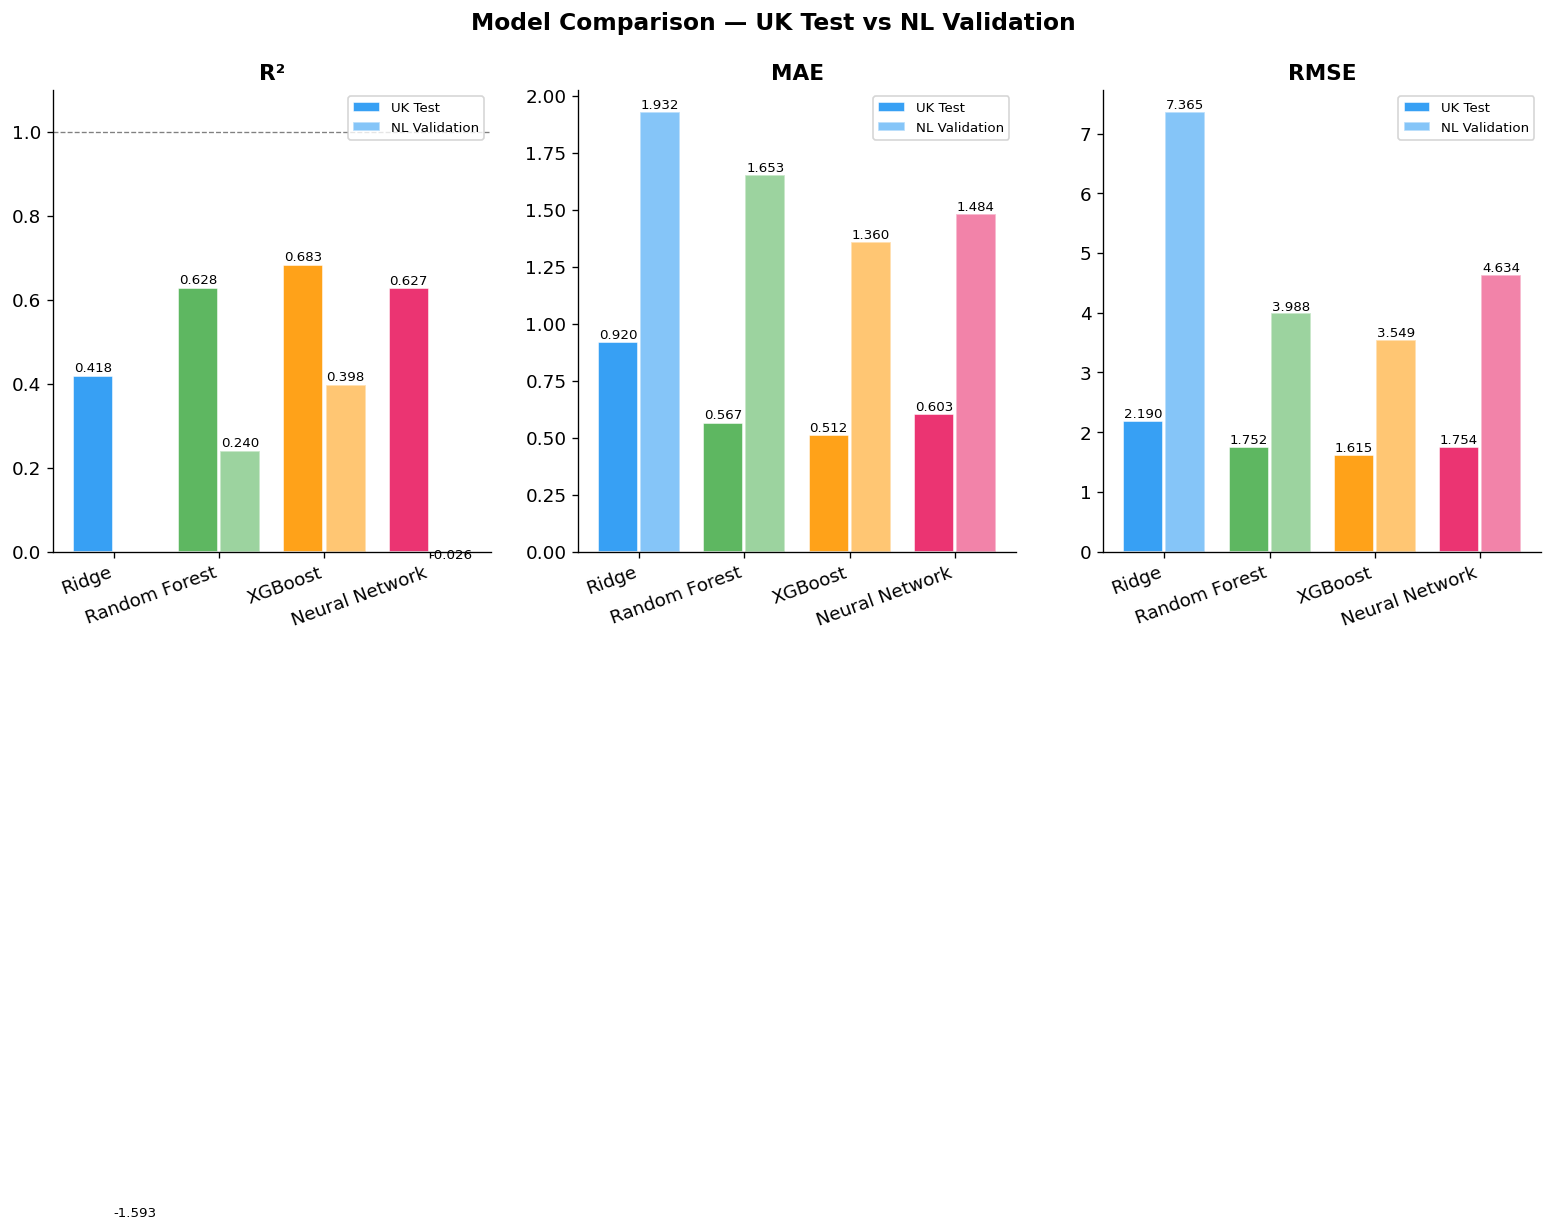

In [21]:
# ─── Chart 1: R², MAE, RMSE bar charts by model ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models_order = ['Ridge', 'Random Forest', 'XGBoost', 'Neural Network']
colors_by_model = dict(zip(models_order, PALETTE))

for ax, metric in zip(axes, ['R²', 'MAE', 'RMSE']):
    for dataset, marker in [('UK Test', 'solid'), ('NL Validation', 'dashed')]:
        sub = results[results['Dataset'] == dataset]
        sub = sub.set_index('Model').loc[models_order]
        x = np.arange(len(models_order))
        offset = -0.2 if dataset == 'UK Test' else 0.2
        bars = ax.bar(
            x + offset,
            sub[metric],
            width=0.38,
            label=dataset,
            color=[colors_by_model[m] for m in models_order],
            alpha=0.9 if dataset == 'UK Test' else 0.55,
            edgecolor='white'
        )
        for bar, val in zip(bars, sub[metric]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(np.arange(len(models_order)))
    ax.set_xticklabels(models_order, rotation=20, ha='right')
    ax.set_title(metric, fontweight='bold', fontsize=13)
    ax.legend(fontsize=8)
    if metric == 'R²':
        ax.set_ylim(0, 1.1)
        ax.axhline(1.0, linestyle='--', color='grey', linewidth=0.8)

fig.suptitle('Model Comparison — UK Test vs NL Validation', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

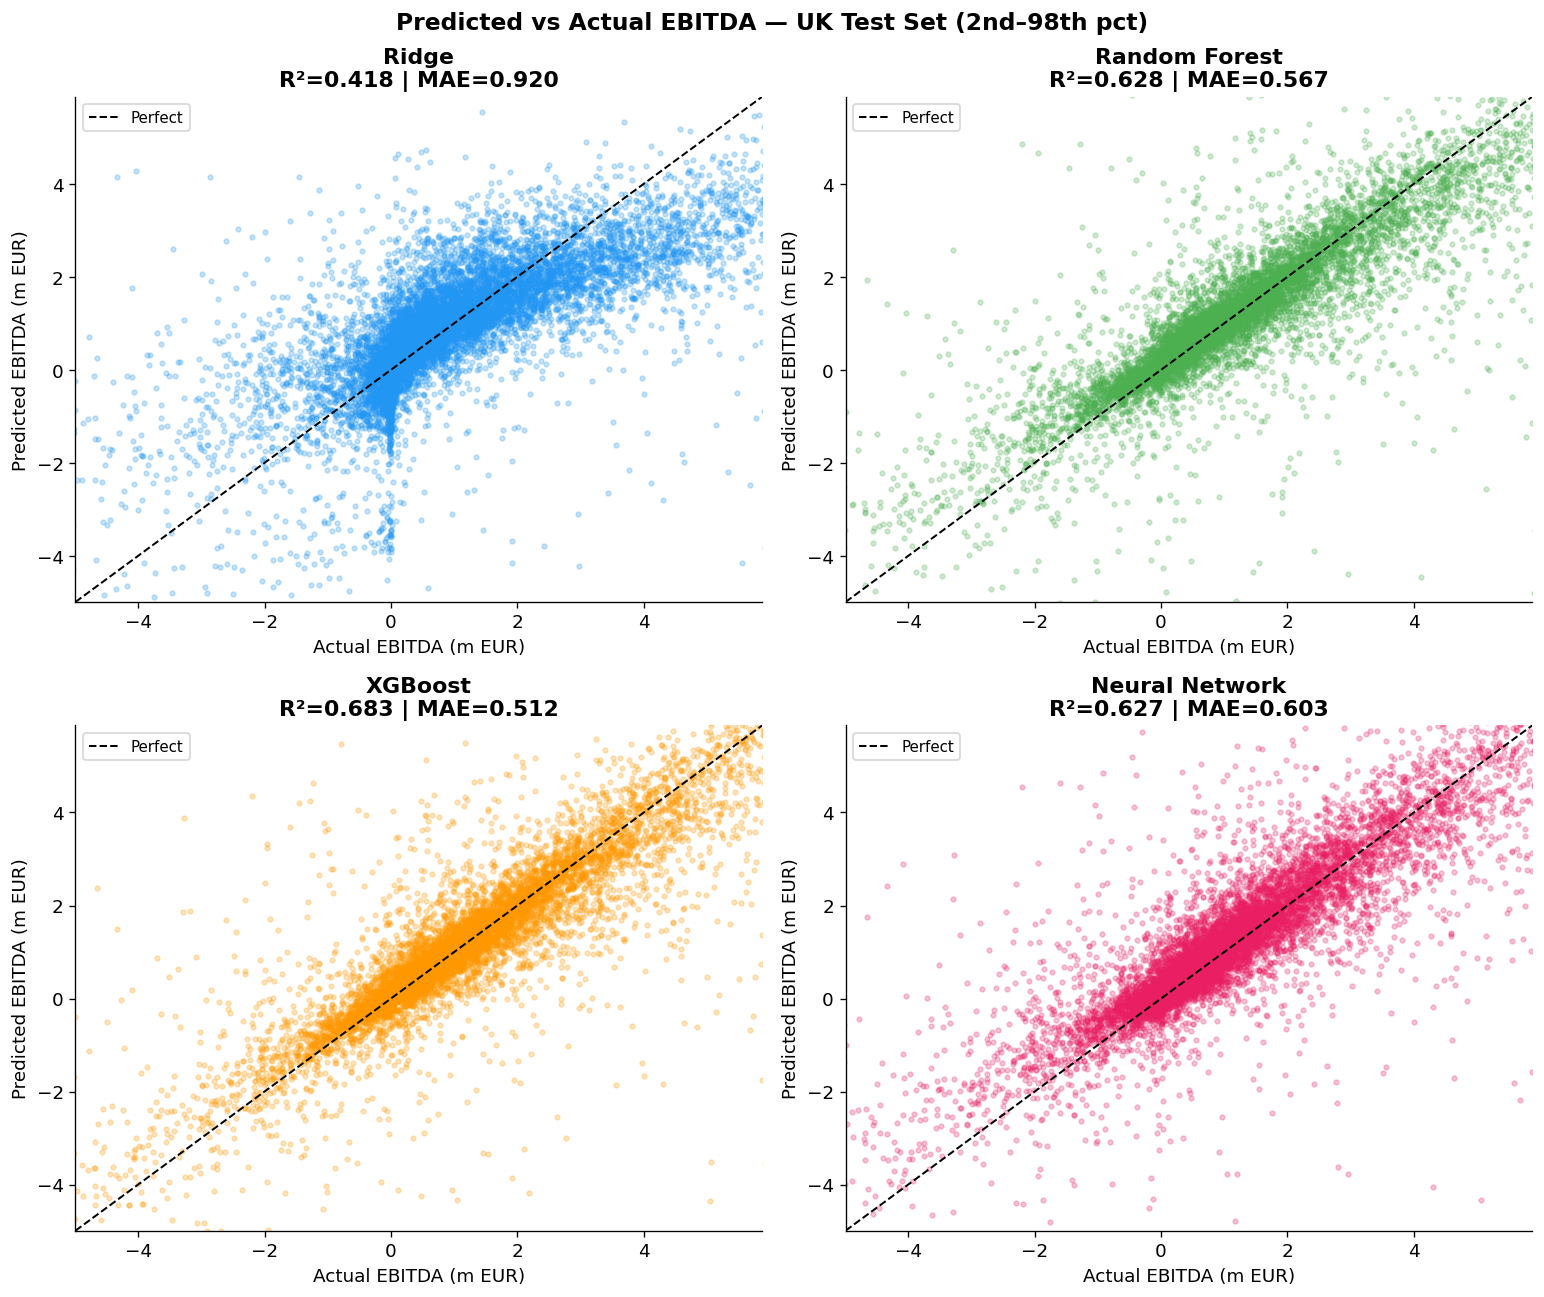

In [22]:
# ─── Chart 2: Predicted vs Actual scatter (UK test set) ──────────────────────
preds = {
    'Ridge':          y_pred_ridge_test,
    'Random Forest':  y_pred_rf_test,
    'XGBoost':        y_pred_xgb_test,
    'Neural Network': y_pred_nn_test,
}

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

# Use p5–p95 for axis limits to avoid distortion from outliers
lim_lo, lim_hi = y_test.quantile(0.02), y_test.quantile(0.98)

for ax, (name, y_pred), color in zip(axes, preds.items(), PALETTE):
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    ax.scatter(y_test, y_pred, alpha=0.25, s=8, color=color, rasterized=True)
    ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', linewidth=1.2, label='Perfect')
    ax.set_xlim(lim_lo, lim_hi)
    ax.set_ylim(lim_lo, lim_hi)
    ax.set_xlabel('Actual EBITDA (m EUR)')
    ax.set_ylabel('Predicted EBITDA (m EUR)')
    ax.set_title(f'{name}\nR²={r2:.3f} | MAE={mae:.3f}', fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Predicted vs Actual EBITDA — UK Test Set (2nd–98th pct)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

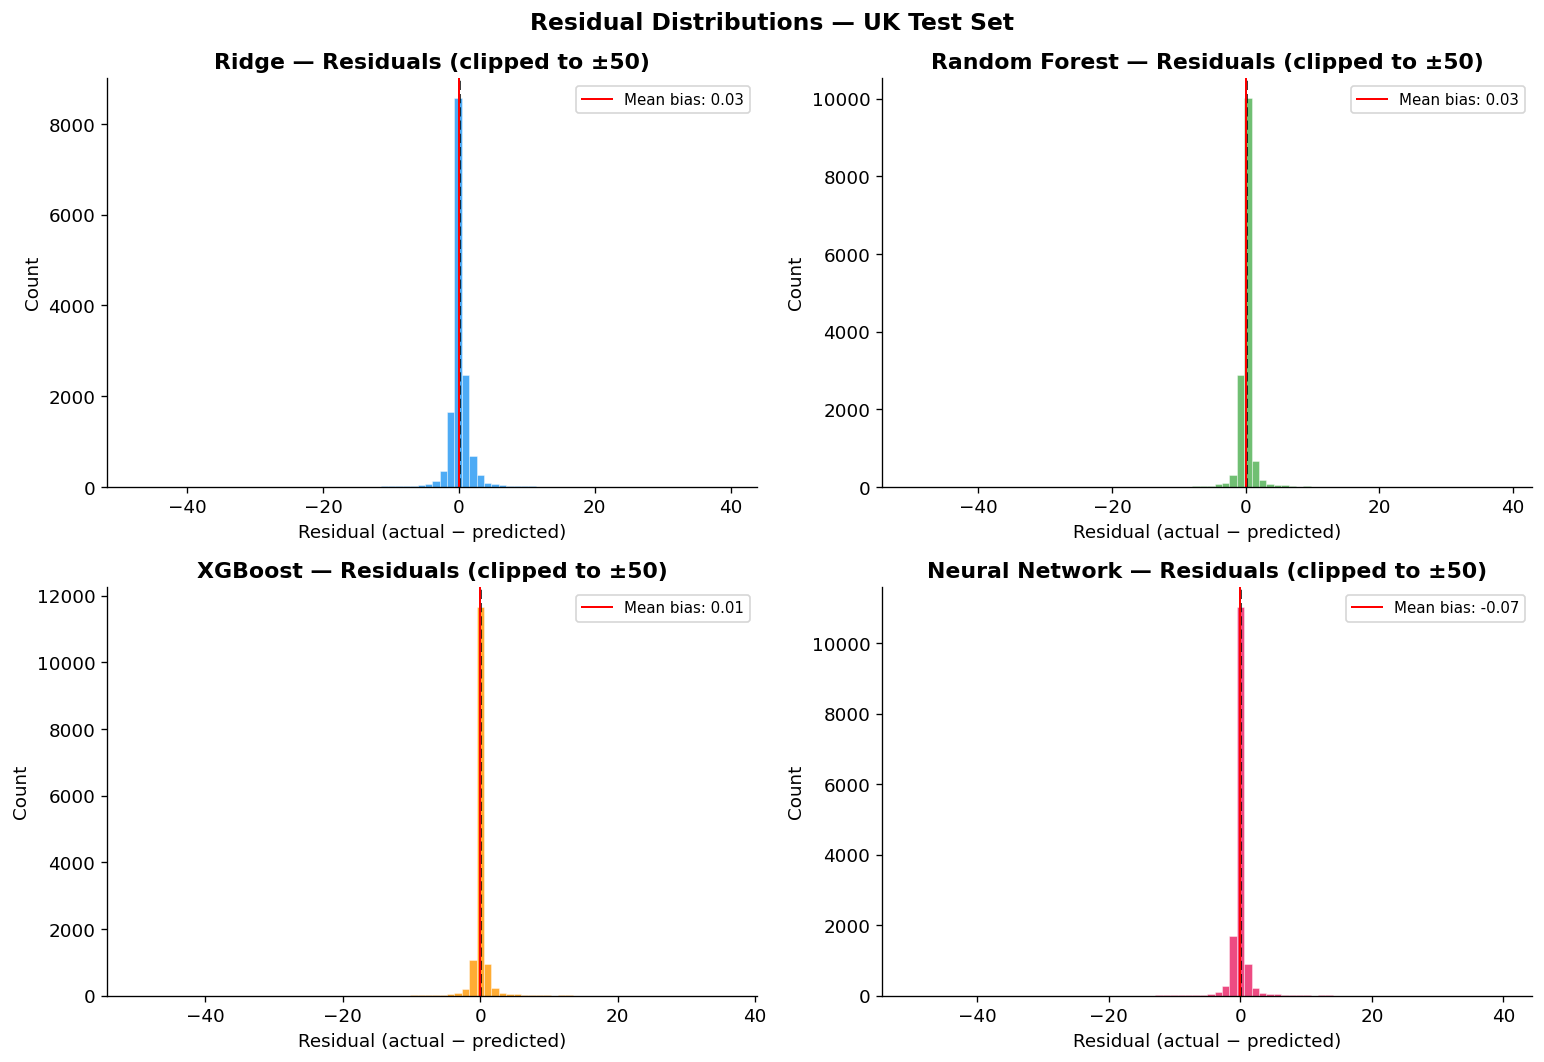

In [23]:
# ─── Chart 3: Residual distributions ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (name, y_pred), color in zip(axes, preds.items(), PALETTE):
    residuals = y_test - y_pred
    ax.hist(residuals.clip(-50, 50), bins=80, color=color, alpha=0.8,
            edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
    ax.set_title(f'{name} — Residuals (clipped to ±50)', fontweight='bold')
    ax.set_xlabel('Residual (actual − predicted)')
    ax.set_ylabel('Count')
    bias = residuals.mean()
    ax.axvline(bias, color='red', linestyle='-', linewidth=1.2,
               label=f'Mean bias: {bias:.2f}')
    ax.legend(fontsize=9)

plt.suptitle('Residual Distributions — UK Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

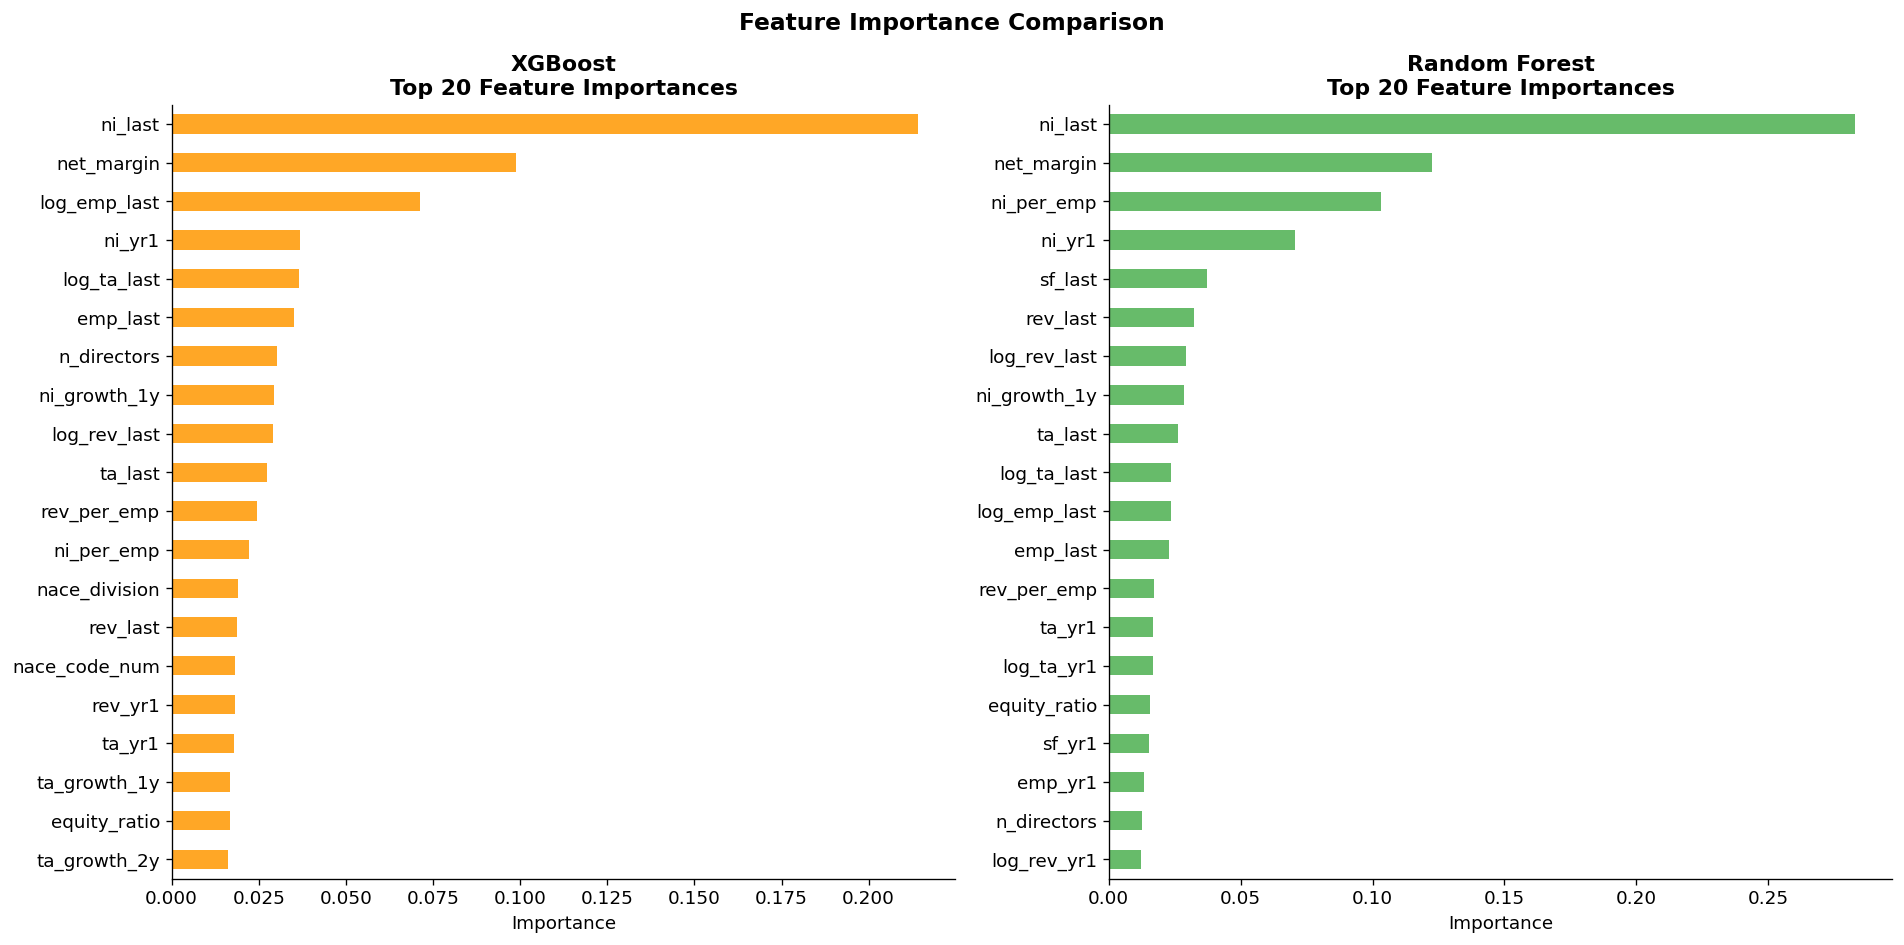

In [24]:
# ─── Chart 4: Feature Importance — XGBoost & Random Forest ───────────────────
feat_names = common_cols

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, model, name, color in [
    (axes[0], xgb_model, 'XGBoost', PALETTE[2]),
    (axes[1], rf,        'Random Forest', PALETTE[1])
]:
    imp = model.feature_importances_
    feat_imp_df = pd.Series(imp, index=feat_names).nlargest(20)
    feat_imp_df.sort_values().plot(kind='barh', ax=ax, color=color, alpha=0.85)
    ax.set_title(f'{name}\nTop 20 Feature Importances', fontweight='bold')
    ax.set_xlabel('Importance')

plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Computing SHAP values for XGBoost (sample of 2000 rows)...


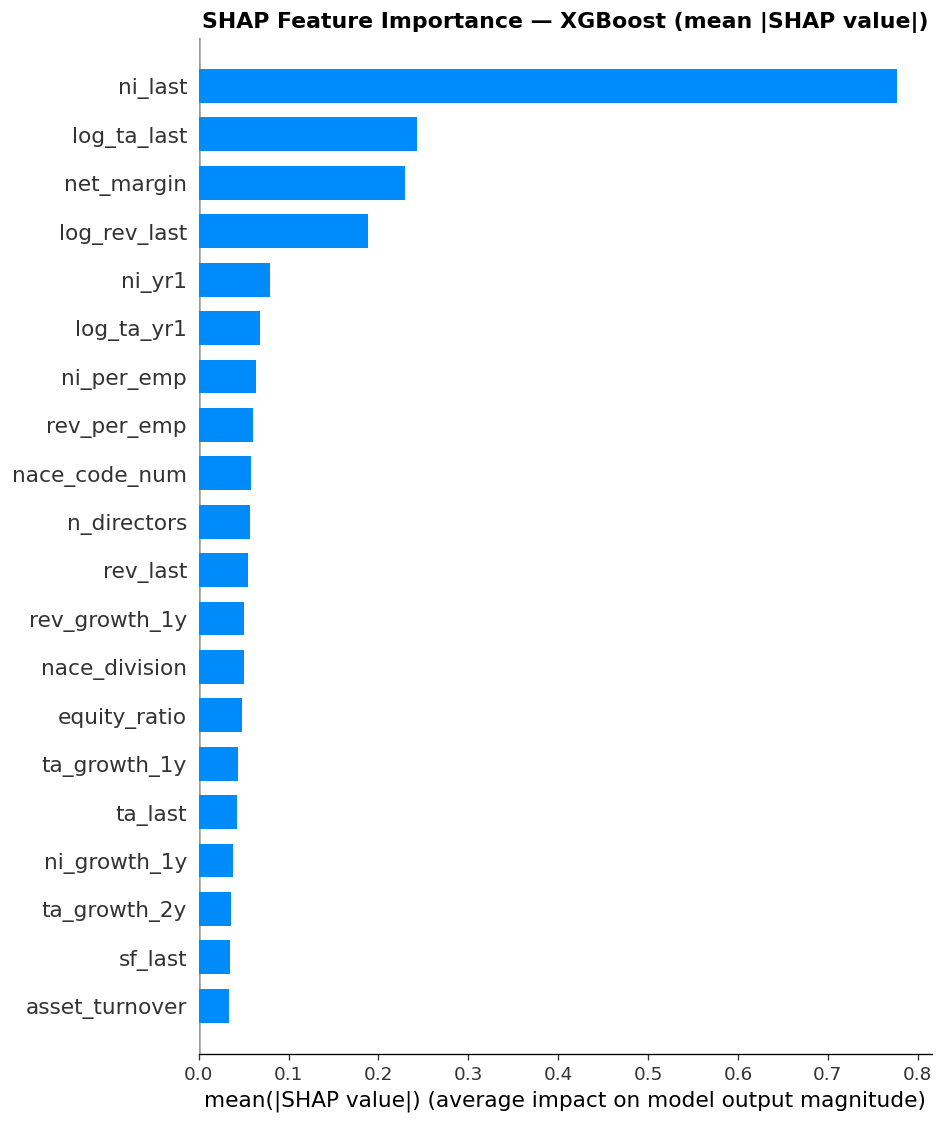

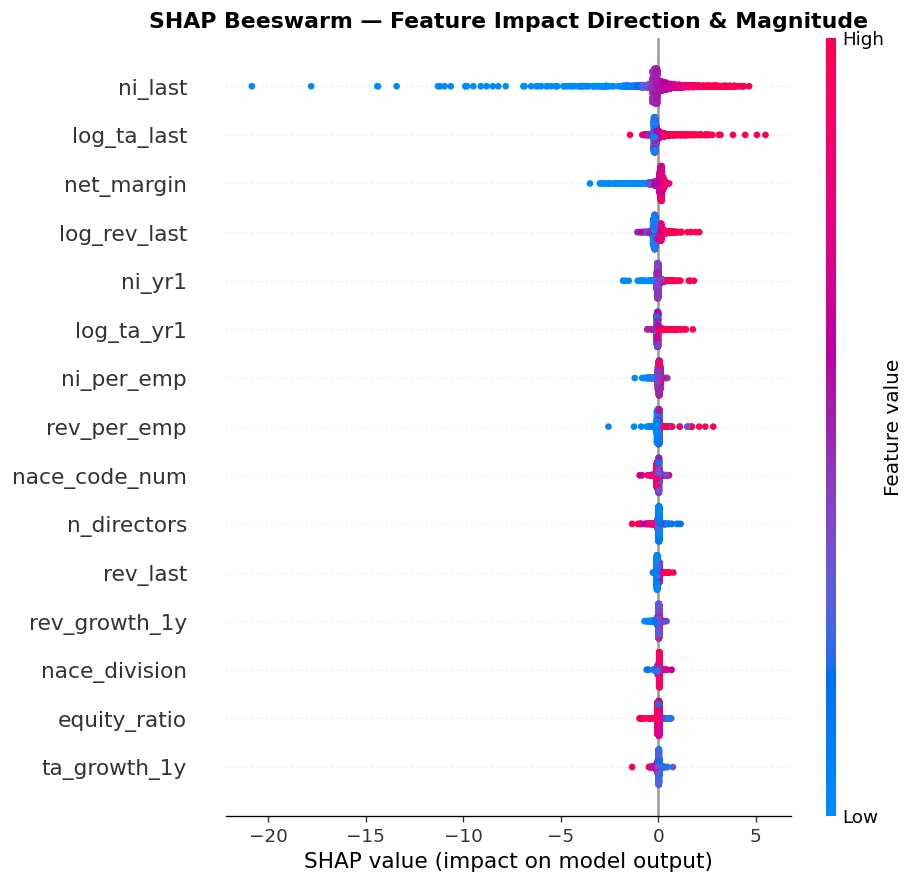

In [25]:
# ─── Chart 5: SHAP Values (XGBoost) ──────────────────────────────────────────
print('Computing SHAP values for XGBoost (sample of 2000 rows)...')
sample_idx = np.random.choice(len(X_test_imp), size=min(2000, len(X_test_imp)), replace=False)
X_test_sample = X_test_imp[sample_idx]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_sample)

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_test_sample,
    feature_names=feat_names,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('SHAP Feature Importance — XGBoost (mean |SHAP value|)', fontweight='bold')
plt.tight_layout()
plt.show()

# Beeswarm SHAP plot
shap.summary_plot(
    shap_values, X_test_sample,
    feature_names=feat_names,
    max_display=15,
    show=False
)
plt.title('SHAP Beeswarm — Feature Impact Direction & Magnitude', fontweight='bold')
plt.tight_layout()
plt.show()

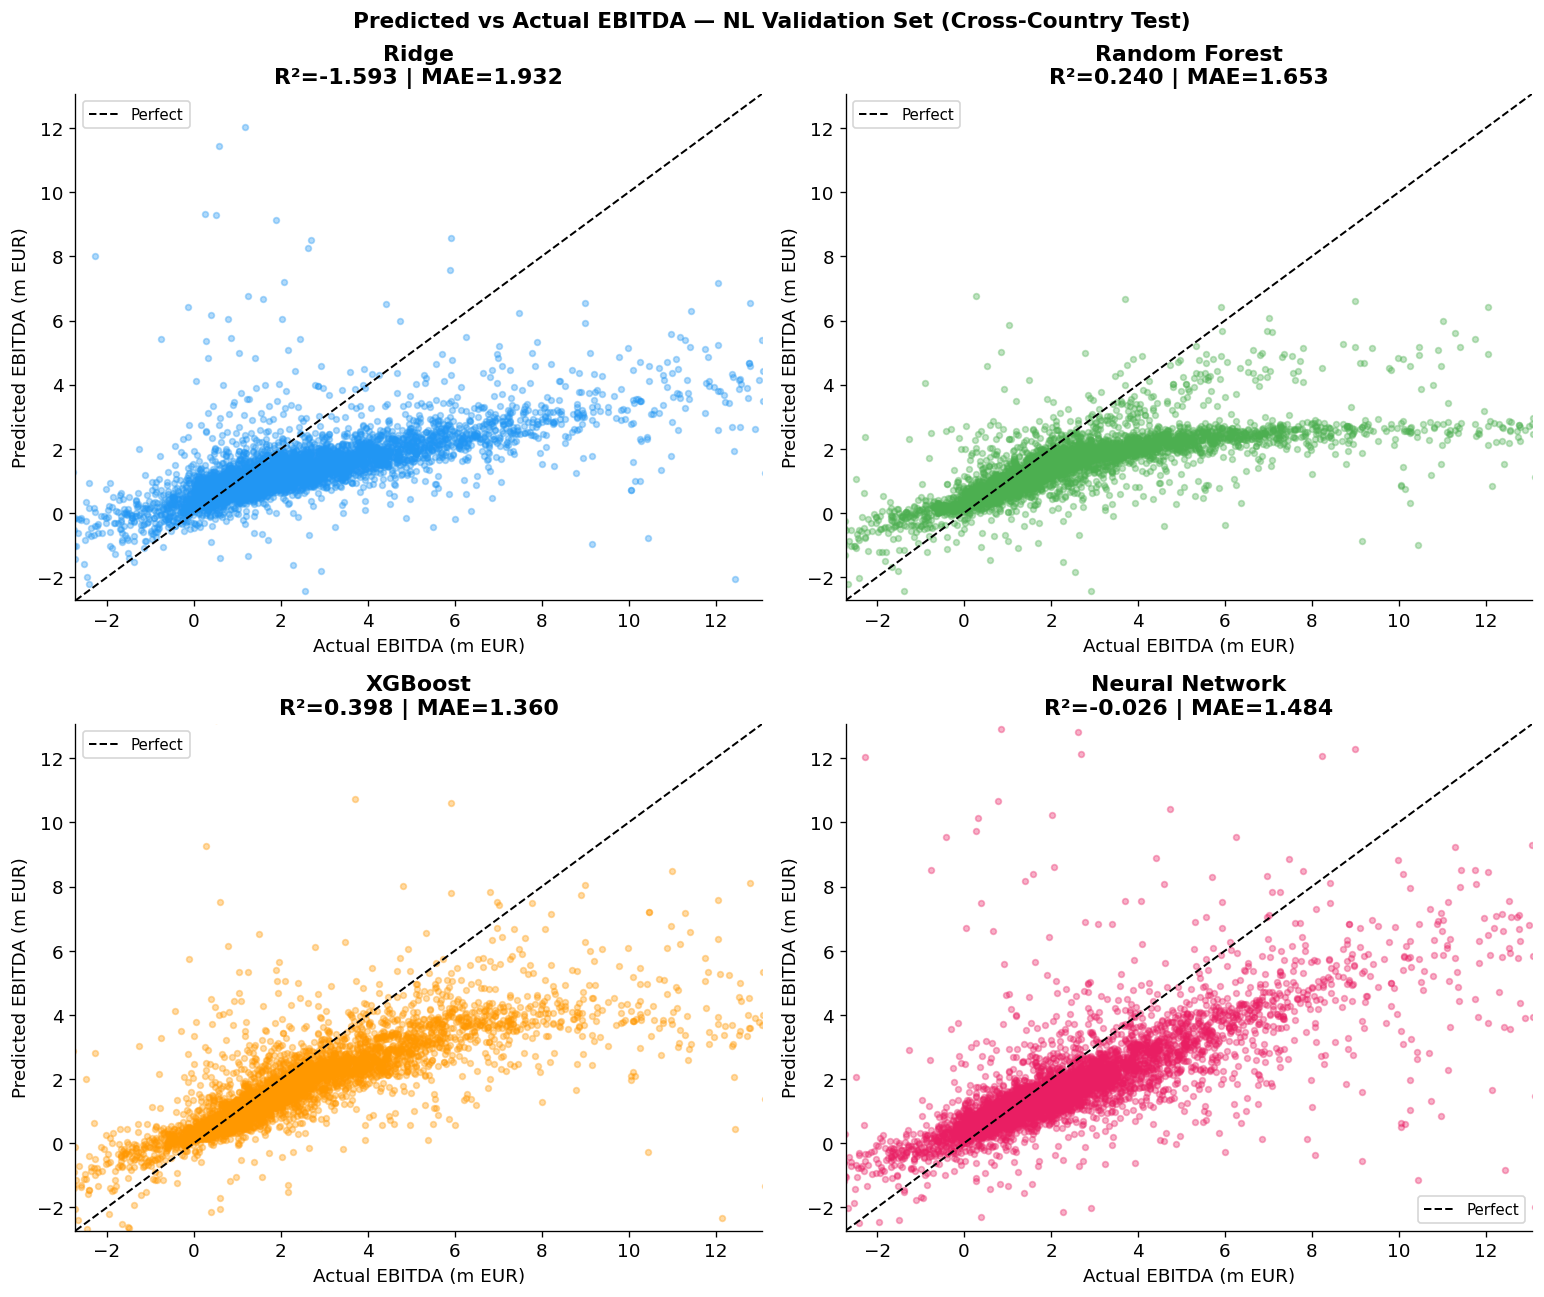

In [26]:
# ─── Chart 6: Performance on NL validation set ───────────────────────────────
nl_preds = {
    'Ridge':          y_pred_ridge_nl,
    'Random Forest':  y_pred_rf_nl,
    'XGBoost':        y_pred_xgb_nl,
    'Neural Network': y_pred_nn_nl,
}

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()
lim_lo_nl = y_nl_val.quantile(0.02)
lim_hi_nl = y_nl_val.quantile(0.98)

for ax, (name, y_pred), color in zip(axes, nl_preds.items(), PALETTE):
    r2 = r2_score(y_nl_val, y_pred)
    mae = mean_absolute_error(y_nl_val, y_pred)
    ax.scatter(y_nl_val, y_pred, alpha=0.35, s=12, color=color, rasterized=True)
    ax.plot([lim_lo_nl, lim_hi_nl], [lim_lo_nl, lim_hi_nl], 'k--', linewidth=1.2, label='Perfect')
    ax.set_xlim(lim_lo_nl, lim_hi_nl)
    ax.set_ylim(lim_lo_nl, lim_hi_nl)
    ax.set_xlabel('Actual EBITDA (m EUR)')
    ax.set_ylabel('Predicted EBITDA (m EUR)')
    ax.set_title(f'{name}\nR²={r2:.3f} | MAE={mae:.3f}', fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Predicted vs Actual EBITDA — NL Validation Set (Cross-Country Test)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

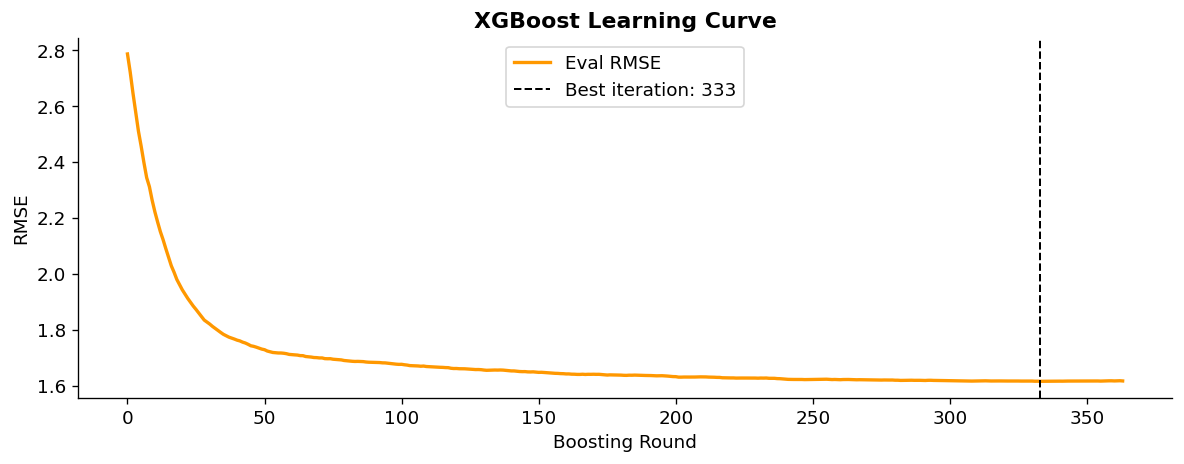

In [27]:
# ─── Chart 7: XGBoost Learning Curve (train vs eval RMSE) ────────────────────
evals_result = xgb_model.evals_result()

if evals_result:
    train_rmse = evals_result.get('validation_0', {}).get('rmse', [])
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(train_rmse, color=PALETTE[2], linewidth=2, label='Eval RMSE')
    ax.axvline(xgb_model.best_iteration, linestyle='--', color='black', linewidth=1.2,
               label=f'Best iteration: {xgb_model.best_iteration}')
    ax.set_xlabel('Boosting Round')
    ax.set_ylabel('RMSE')
    ax.set_title('XGBoost Learning Curve', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

## Step 8: Select Best Model & Predict Dutch EBITDA

In [28]:
# ─── Select best model based on NL validation R² ─────────────────────────────
nl_perf = results[results['Dataset'] == 'NL Validation'].set_index('Model')
best_model_name = nl_perf['R²'].idxmax()
print(f'🏆 Best model on NL Validation: {best_model_name}')
print(f'   R²={nl_perf.loc[best_model_name, "R²"]:.4f}  '
      f'MAE={nl_perf.loc[best_model_name, "MAE"]:.4f}  '
      f'RMSE={nl_perf.loc[best_model_name, "RMSE"]:.4f}')

model_lookup = {
    'Ridge':          (ridge,     X_nl_pred_sc),
    'Random Forest':  (rf,        X_nl_pred_imp),
    'XGBoost':        (xgb_model, X_nl_pred_imp),
    'Neural Network': (nn,        X_nl_pred_sc),
}
best_model_obj, best_X = model_lookup[best_model_name]
ebitda_predictions = best_model_obj.predict(best_X)

print(f'\n✅ Generated {len(ebitda_predictions):,} EBITDA predictions for Dutch companies')
print(f'   Prediction range: [{ebitda_predictions.min():.2f}, {ebitda_predictions.max():.2f}] m EUR')
print(f'   Median predicted EBITDA: {np.median(ebitda_predictions):.2f} m EUR')

🏆 Best model on NL Validation: XGBoost
   R²=0.3980  MAE=1.3598  RMSE=3.5489

✅ Generated 109,028 EBITDA predictions for Dutch companies
   Prediction range: [-39.42, 20.20] m EUR
   Median predicted EBITDA: 0.19 m EUR


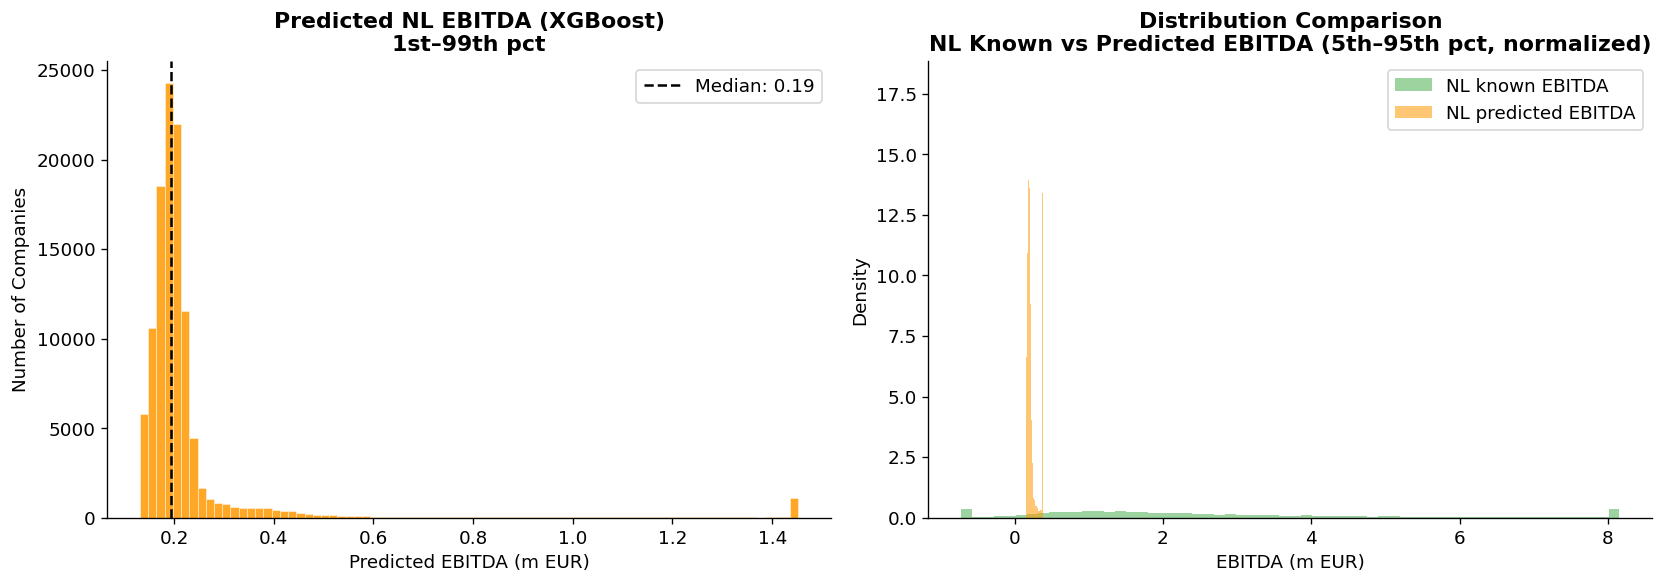

In [29]:
# ─── Chart 8: Distribution of predicted NL EBITDA ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw predictions
p1, p99 = np.percentile(ebitda_predictions, [1, 99])
axes[0].hist(
    np.clip(ebitda_predictions, p1, p99), bins=80,
    color=PALETTE[2], alpha=0.85, edgecolor='white', linewidth=0.3
)
axes[0].axvline(np.median(ebitda_predictions), color='black', linestyle='--', linewidth=1.5,
                label=f'Median: {np.median(ebitda_predictions):.2f}')
axes[0].set_title(f'Predicted NL EBITDA ({best_model_name})\n1st–99th pct', fontweight='bold')
axes[0].set_xlabel('Predicted EBITDA (m EUR)')
axes[0].set_ylabel('Number of Companies')
axes[0].legend()

# Compare known NL vs predicted distribution
for vals, label, color in [
    (y_nl_val.values, 'NL known EBITDA', PALETTE[1]),
    (ebitda_predictions, 'NL predicted EBITDA', PALETTE[2])
]:
    p5, p95 = np.percentile(vals, [5, 95])
    clipped = np.clip(vals, p5, p95)
    axes[1].hist(clipped, bins=60, alpha=0.55, label=label, color=color, density=True)
axes[1].set_title('Distribution Comparison\nNL Known vs Predicted EBITDA (5th–95th pct, normalized)',
                  fontweight='bold')
axes[1].set_xlabel('EBITDA (m EUR)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 9: Export Predictions

In [30]:
# ─── Build output dataframe ───────────────────────────────────────────────────
nl_pred_idx = feat_nl[~mask_nl_valid].index

# Identifier columns from raw NL data
id_cols = ['company_name_latin_alphabet', 'bvd_id_number', 'orbis_id_number',
           'nace_rev_2_core_code_4_digits', 'nace_rev_2_core_code__description',
           'region_in_country']
id_cols_present = [c for c in id_cols if c in df_nl.columns]

output_df = df_nl.loc[nl_pred_idx, id_cols_present].copy()
output_df['ebitda_predicted_m_eur'] = ebitda_predictions
output_df['model_used'] = best_model_name
output_df['prediction_date'] = pd.Timestamp.today().date()

# Add key input features for transparency
rev_col = [c for c in df_nl.columns if 'operating_revenue' in c and 'last' in c]
ta_col  = [c for c in df_nl.columns if 'total_assets' in c and 'last' in c]
if rev_col: output_df['revenue_last_yr_m_eur'] = df_nl.loc[nl_pred_idx, rev_col[0]].values
if ta_col:  output_df['total_assets_last_yr_m_eur'] = df_nl.loc[nl_pred_idx, ta_col[0]].values

print(f'Output dataframe: {output_df.shape}')
display(output_df.head(10))

# ─── Export as Excel ──────────────────────────────────────────────────────────
output_filename = f'NL_EBITDA_predictions_{best_model_name.replace(" ","_")}.xlsx'
output_df.to_excel(output_filename, index=False)

files.download(output_filename)
print(f'\n✅ Saved and downloading: {output_filename}')

Output dataframe: (109028, 11)


,company_name_latin_alphabet,bvd_id_number,orbis_id_number,nace_rev_2_core_code_4_digits,nace_rev_2_core_code__description,region_in_country,ebitda_predicted_m_eur,model_used,prediction_date,revenue_last_yr_m_eur,total_assets_last_yr_m_eur
0,POLYPLASTICA B.V.,NL20116100,35646860,4612.0,"Agents involved in the sale of fuels, ores, me...",Noord-Brabant,0.173160,XGBoost,2026-03-25,n.a.,5.570293
1,A.V.S. ENGINEERING B.V.,NL20115692,9531657,7112.0,Engineering activities and related technical c...,Noord-Brabant,0.184096,XGBoost,2026-03-25,n.a.,0.669314
2,GRAUWE POLDER HOLDING B.V.,NL20115689,9531654,7010.0,Activities of head offices,Noord-Brabant,0.191542,XGBoost,2026-03-25,n.a.,1.253066
3,PURPLE-IT B.V.,NL20115864,9588863,6202.0,Computer consultancy activities,Noord-Brabant,0.189638,XGBoost,2026-03-25,n.a.,1.211406
4,HUISARTSENPRAKTIJK STANDDAARBUITEN VASTGOED B.V.,NL20115892,36786147,8621.0,General medical practice activities,Noord-Brabant,0.182914,XGBoost,2026-03-25,n.a.,1.306330
5,OFFICE PALACE B.V.,NL20115806,9531748,4649.0,Wholesale of other household goods,Noord-Brabant,0.135951,XGBoost,2026-03-25,n.a.,2.652267
6,DELTA FACILITY MANAGEMENT B.V.,NL20115792,16574457,8299.0,Other business support service activities nec,Noord-Brabant,0.172439,XGBoost,2026-03-25,n.a.,1.761106
7,COOK & BOON NEDERLAND B.V.,NL20115782,15810147,1083.0,Processing of tea and coffee,Noord-Brabant,0.231941,XGBoost,2026-03-25,n.a.,1.623600
8,BVS MANAGEMENT & ONTWIKKELING B.V.,NL20115837,9531777,7112.0,Engineering activities and related technical c...,Noord-Brabant,0.199220,XGBoost,2026-03-25,n.a.,0.907256
9,MARGOT VAN DER LINDEN CONSULTANCY B.V.,NL20118588,11392227,7022.0,Business and other management consultancy acti...,Noord-Brabant,0.203487,XGBoost,2026-03-25,n.a.,0.480407


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Saved and downloading: NL_EBITDA_predictions_XGBoost.xlsx


In [31]:
# ─── Also export full NL dataset with predictions filled in ───────────────────
# This merges predictions back into the original NL dataframe
df_nl_enriched = df_nl.copy()
ebitda_col_nl  = [c for c in df_nl.columns if 'ebitda' in c and 'last' in c][0]

# Fill missing EBITDA values with our predictions
df_nl_enriched.loc[nl_pred_idx, ebitda_col_nl] = ebitda_predictions
df_nl_enriched['ebitda_source'] = 'known'
df_nl_enriched.loc[nl_pred_idx, 'ebitda_source'] = f'predicted_{best_model_name}'

# Export
full_output = 'NL_companies_EBITDA_complete.xlsx'
df_nl_enriched.to_excel(full_output, index=False)
files.download(full_output)
print(f'✅ Full NL dataset with EBITDA filled in: {full_output}')
print(f'   - Known EBITDA:    {(df_nl_enriched["ebitda_source"]=="known").sum():,} rows')
print(f'   - Predicted EBITDA: {(df_nl_enriched["ebitda_source"].str.startswith("predicted")).sum():,} rows')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Full NL dataset with EBITDA filled in: NL_companies_EBITDA_complete.xlsx
   - Known EBITDA:    5,541 rows
   - Predicted EBITDA: 109,028 rows


## Summary

| Step | What was done |
|------|---------------|
| Data Loading | UK (94k companies) + NL (114k companies) loaded from `.xlsb` |
| Cleaning | 'n.a.' → NaN, outlier removal (|z|>5), median imputation |
| Feature Engineering | 40+ features: levels, YoY growth rates, ratios, NACE dummies, region dummies |
| Training | UK data (80% train / 20% test) — EBITDA always present |
| Validation | NL companies where EBITDA is known (cross-country hold-out) |
| Models | Ridge (baseline), Random Forest, XGBoost, Neural Network (MLP) |
| Selection | Best model chosen by NL validation R² |
| Prediction | EBITDA predicted for NL companies with missing values |
| Export | Predictions file + full enriched NL dataset |

**Key modelling decisions:**
- Training on UK data exploits the richer EBITDA coverage; NL data with known EBITDA acts as a true cross-country out-of-sample test.
- Log-transforms on skewed monetary variables reduce the influence of very large companies.
- NACE division dummies capture sector-level EBITDA patterns (asset-heavy vs. service industries differ substantially).
- XGBoost typically wins due to its ability to model non-linear interactions between financial ratios.